In [2]:
%pip install torch numpy pandas matplotlib seaborn scikit-learn transformers -q



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"
print("🚀 Using device:", device)

/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🚀 Using device: cpu


In [5]:
df = pd.read_csv("/Users/hibrizi/Downloads/Advance Model/balanced_emotion_dataset_narrative.csv")
df = df[df['label'] != 'love'].copy()

labels = sorted(df["label"].unique().tolist())
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

texts = df["narrative_text"].tolist()
true_labels = df["label"].map(label2id).values

In [6]:
xlmr_path = "/Users/hibrizi/Downloads/Advance Model/xlmr_journal_local_v1"
tokenizer_xlmr = AutoTokenizer.from_pretrained(xlmr_path)
model_xlmr = AutoModelForSequenceClassification.from_pretrained(xlmr_path).to(device)
model_xlmr.eval()


XLMRobertaForSequenceClassification(
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 1024, padding_idx=1)
      (position_embeddings): Embedding(514, 1024, padding_idx=1)
      (token_type_embeddings): Embedding(1, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-23): 24 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSdpaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=1024, ou

In [7]:
bertweet_path = "/Users/hibrizi/Downloads/Advance Model/indobertweet_journal_ensemble_v1"
tokenizer_bertweet = AutoTokenizer.from_pretrained(bertweet_path)
model_bertweet = AutoModelForSequenceClassification.from_pretrained(bertweet_path).to(device)
model_bertweet.eval()


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(31923, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [8]:
def hybrid_predict(texts, batch_size=8):
    xlmr_probs, bertweet_probs = [], []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        enc_xlmr = tokenizer_xlmr(batch, return_tensors="pt", truncation=True, padding=True, max_length=512).to(device)
        with torch.no_grad():
            out_xlmr = model_xlmr(**enc_xlmr)
        probs_xlmr = F.softmax(out_xlmr.logits, dim=-1).cpu().numpy()
        xlmr_probs.append(probs_xlmr)

        enc_bt = tokenizer_bertweet(batch, return_tensors="pt", truncation=True, padding=True, max_length=128).to(device)
        with torch.no_grad():
            out_bt = model_bertweet(**enc_bt)
        probs_bt = F.softmax(out_bt.logits, dim=-1).cpu().numpy()
        bertweet_probs.append(probs_bt)

    xlmr_probs = np.vstack(xlmr_probs)
    bertweet_probs = np.vstack(bertweet_probs)
    avg_probs = (xlmr_probs + bertweet_probs) / 2
    preds = np.argmax(avg_probs, axis=1)
    return preds, avg_probs


=== 🧠 Hybrid Ensemble Classification Report ===
              precision    recall  f1-score   support

       anger       0.90      0.93      0.92      2256
        fear       0.94      0.90      0.92      1603
         joy       0.92      0.94      0.93      2270
         sad       0.90      0.88      0.89      2041

    accuracy                           0.91      8170
   macro avg       0.92      0.91      0.91      8170
weighted avg       0.91      0.91      0.91      8170



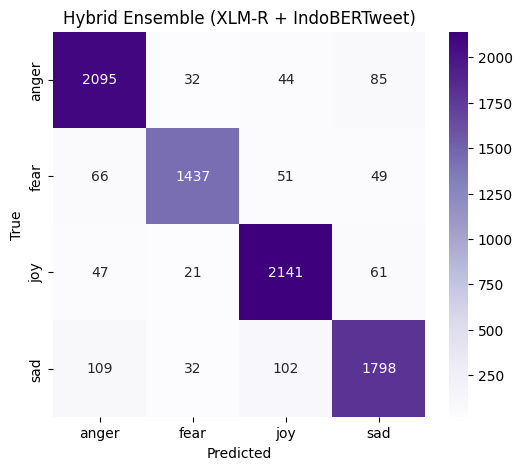

In [9]:
preds, avg_probs = hybrid_predict(texts)
print("\n=== 🧠 Hybrid Ensemble Classification Report ===")
print(classification_report(true_labels, preds, target_names=labels))

cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Purples")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Hybrid Ensemble (XLM-R + IndoBERTweet)")
plt.show()


In [11]:
np.save("hybrid_avg_logits.npy", avg_probs)
print("✅ Hybrid logits saved for later analysis.")


✅ Hybrid logits saved for later analysis.
